EP2 - Reconhecimento de Folhas de Plantas

Parte 1: Pré-processamento de Imagens

Ísis Ardisson Logullo - 7577410

1. Configurações Iniciais e Carregamento do Dataset

Mapeamento de cada tipo de planta para os seus respectivos intervalos de arquivos, conforme especificado na tabela. As imagens são carregadas da pasta standardleaves, estruturando-as em um dicionário para fácil acesso nas etapas subsequentes de pré-processamento. As imagens sâo baixadas de uma pasta pública no drive, para a pasta local mencionada acima.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['image.cmap'] = 'gray'

LINK_DO_DRIVE = "https://drive.google.com/drive/folders/1fOhA38yFyjroNLTtFTiqIqChyF50_JUG?usp=sharing"
DIRETORIO_DATASET = "standardleaves"

def baixar_e_carregar_imagens(link_drive, diretorio_destino):
    if not os.path.exists(diretorio_destino):
        print("Pasta local não encontrada. Iniciando download direto do Google Drive...")
        try:
            import gdown
        except ImportError:
            import subprocess
            subprocess.run(["pip", "install", "gdown"])
            import gdown

        try:
            id_da_pasta = link_drive.split("folders/")[1].split("?")[0]
            gdown.download_folder(id=id_da_pasta, output=diretorio_destino, quiet=False, remaining_ok=True)
        except Exception as e:
            print(f"Erro ao tentar extrair o ID do link ou fazer o download: {e}")
            return {}
    else:
        print(f"A pasta '{diretorio_destino}' já existe. Pulando download e lendo os arquivos.")

    dataset_direto = {}
    arquivos_locais = os.listdir(diretorio_destino)
    print(f"Total de arquivos físicos detectados na pasta: {len(arquivos_locais)}")

    print("\nIniciando o carregamento das imagens...")
    for nome_arquivo in arquivos_locais:
        nome_puro, extensao = os.path.splitext(nome_arquivo)

        if nome_puro.isdigit() and extensao.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
            numero_id = int(nome_puro)
            caminho_completo = os.path.join(diretorio_destino, nome_arquivo)

            try:
                img_array = plt.imread(caminho_completo)
                dataset_direto[numero_id] = img_array
            except Exception as err:
                print(f"Erro ao ler o arquivo {nome_arquivo}: {err}")

    print(f"Concluído! Total de imagens salvas na memória: {len(dataset_direto)}")
    return dataset_direto

folhas_dados_direto = baixar_e_carregar_imagens(LINK_DO_DRIVE, DIRETORIO_DATASET)

A pasta 'standardleaves' já existe. Pulando download e lendo os arquivos.
Total de arquivos físicos detectados na pasta: 32

Iniciando o carregamento das imagens...
Concluído! Total de imagens salvas na memória: 32


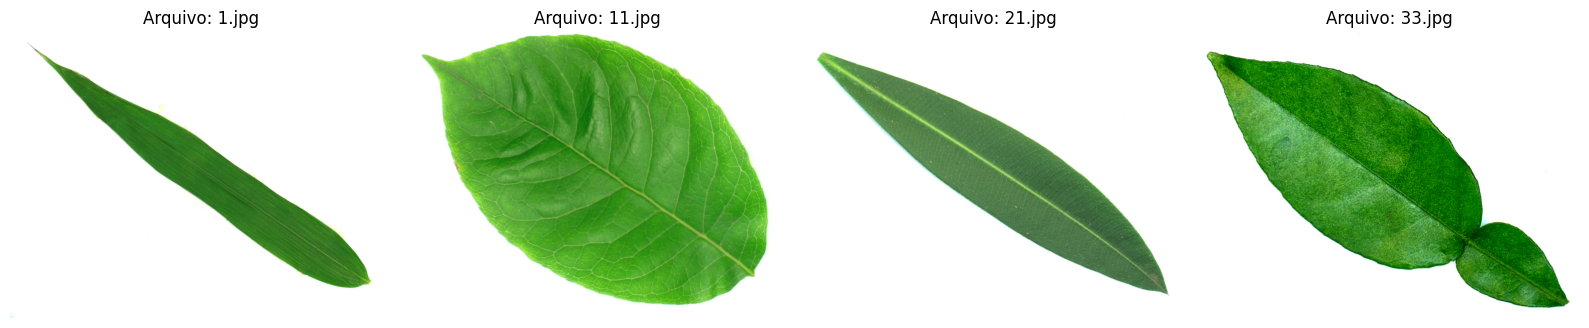

In [25]:
MAPEAMENTO_PLANTAS = {
    1: ("pubescent bamboo", 1001, 1059),
    2: ("Chinese horse chestnut", 1060, 1122),
    3: ("Anhui Barberry", 1552, 1616),
    4: ("Chinese redbud", 1123, 1194),
    5: ("true indigo", 1195, 1267),
    6: ("Japanese maple", 1268, 1323),
    7: ("Nanmu", 1324, 1385),
    8: ("castor aralia", 1386, 1437),
    9: ("Chinese cinnamon", 1497, 1551),
    10: ("goldenrain tree", 1438, 1496),
    11: ("Bigfruited -Holly", 2001, 2050),
    12: ("Japanese cheesewood", 2051, 2113),
    14: ("wintersweet", 2114, 2165),
    15: ("camphortree", 2166, 2230),
    16: ("Japan Arrowwood", 2231, 2290),
    17: ("sweet osmanthus", 2291, 2346),
    18: ("deodar", 2347, 2423),
    19: ("ginkgo, maidenhair tree", 2424, 2485),
    20: ("Crape myrtle, Crepe myrtle", 2486, 2546),
    21: ("oleander", 2547, 2612),
    22: ("yew plum pine", 2616, 2675),
    23: ("Japanese Flowering Cherry", 3001, 3055),
    24: ("Glossy Privet", 3056, 3110),
    25: ("Chinese Toon", 3111, 3175),
    26: ("peach", 3176, 3229),
    27: ("Ford Woodlotus", 3230, 3281),
    28: ("trident maple", 3282, 3334),
    29: ("Beale's barberry", 3335, 3389),
    30: ("southern magnolia", 3390, 3446),
    31: ("Canadian poplar", 3447, 3510),
    32: ("Chinese tulip tree", 3511, 3563),
    33: ("tangerine", 3566, 3621)
}

ID_TESTE = 1

def visualizar_folhas_por_numero(dataset, numeros_para_mostrar):
    qtd = len(numeros_para_mostrar)
    if qtd == 0:
        return

    fig, axes = plt.subplots(1, qtd, figsize=(4 * qtd, 4))
    if qtd == 1:
        axes = [axes]

    for idx, num in enumerate(numeros_para_mostrar):
        if num in dataset:
            img = dataset[num]
            axes[idx].imshow(img)
            axes[idx].set_title(f"Arquivo: {num}.jpg")
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f"Arquivo {num}.jpg\nnão encontrado",
                           ha='center', va='center', color='red')
            axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

if folhas_dados_direto:
    visualizar_folhas_por_numero(folhas_dados_direto, numeros_para_mostrar=[1, 11, 21, 33])

2 - Conversão de RGB para Escala de Cinza

Uma imagem digital colorida geralmente armazena informações espectrais em três canais independentes (Vermelho, Verde e Azul). Para simplificar o processamento da folha, convertemos essa representação tridimensional para uma escala unidimensional de cinza (intensidade de luminância).Utilizamos a fórmula padrão de luminância que pondera os três canais com base na sensibilidade fisiológica do sistema visual humano (somos mais sensíveis ao verde e menos ao azul):

$$Y = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$$

=== METADADOS - PASSO 1 (ESCALA DE CINZA) ===
ID do arquivo testado: 1.jpg
Dimensões da matriz original: (1200, 1600, 3)
Dimensões após conversão: (1200, 1600)
Tipo de dado (Dtype): float64
Intensidade - Mínima: 42.057 | Máxima: 255.0


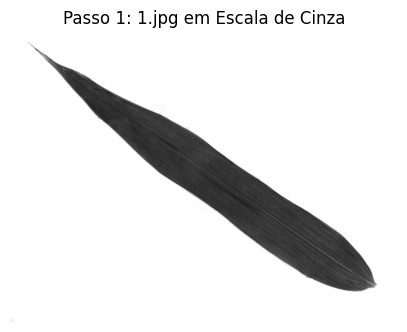

In [26]:
def rgb_para_cinza(img_rgb):
    if len(img_rgb.shape) == 3 and img_rgb.shape[2] >= 3:
        r = img_rgb[:, :, 0]
        g = img_rgb[:, :, 1]
        b = img_rgb[:, :, 2]

        img_cinza = 0.299 * r + 0.587 * g + 0.114 * b
        return img_cinza

    return img_rgb

imagem_original = folhas_dados_direto[ID_TESTE]
imagem_cinza = rgb_para_cinza(imagem_original)

print(f"=== METADADOS - PASSO 1 (ESCALA DE CINZA) ===")
print(f"ID do arquivo testado: {ID_TESTE}.jpg")
print(f"Dimensões da matriz original: {imagem_original.shape}")
print(f"Dimensões após conversão: {imagem_cinza.shape}")
print(f"Tipo de dado (Dtype): {imagem_cinza.dtype}")
print(f"Intensidade - Mínima: {imagem_cinza.min()} | Máxima: {imagem_cinza.max()}")
print(f"=============================================")

plt.figure(figsize=(5, 5))
plt.imshow(imagem_cinza)
plt.title(f"Passo 1: {ID_TESTE}.jpg em Escala de Cinza")
plt.axis('off')
plt.show()

3 - Binarização por Thresholding (Limiarização)

A binarização segmenta o objeto do fundo da imagem. Como o dataset de folhas possui um fundo predominantemente branco e homogêneo, estabeleceu-se um valor de corte estático (limiar ou threshold).

Todos os pixels com intensidade em escala de cinza abaixo deste limiar serão classificados como o objeto (folha) e receberão o valor lógico 1 (branco). Pixels com intensidade superior ao limiar (fundo claro) serão zerados 0 (preto).

=== METADADOS - PASSO 2 (BINARIZAÇÃO) ===
Dimensões da matriz binária: (1200, 1600)
Tipo de dado (Dtype): uint8
Valores únicos na matriz: [0 1]
Contagem de pixels - Objeto (1): 278191 | Fundo (0): 1641809


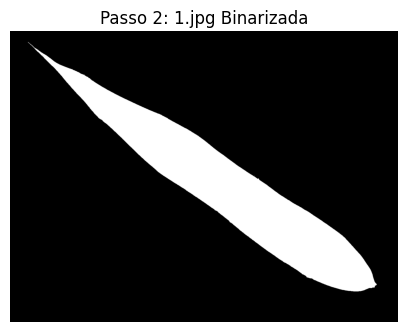

In [28]:
def binarizar_imagem(img_cinza, limiar):
    if img_cinza.max() <= 1.0 and limiar > 1.0:
        limiar /= 255.0

    img_binaria = (img_cinza < limiar).astype(np.uint8)
    return img_binaria

imagem_binaria = binarizar_imagem(imagem_cinza, limiar=200)

print(f"=== METADADOS - PASSO 2 (BINARIZAÇÃO) ===")
print(f"Dimensões da matriz binária: {imagem_binaria.shape}")
print(f"Tipo de dado (Dtype): {imagem_binaria.dtype}")
print(f"Valores únicos na matriz: {np.unique(imagem_binaria)}")
print(f"Contagem de pixels - Objeto (1): {np.sum(imagem_binaria == 1)} | Fundo (0): {np.sum(imagem_binaria == 0)}")
print(f"=========================================")

plt.figure(figsize=(5, 5))
plt.imshow(imagem_binaria)
plt.title(f"Passo 2: {ID_TESTE}.jpg Binarizada")
plt.axis('off')
plt.show()

4 -  Filtro de Ruído por Abertura por Área

A abertura por área localiza pequenos pontos pretos ou ruídos brancos isolados no fundo e os elimina com base em no número total de pixels conectados.

Utilizando BFS nativo sobre a matriz para rotular e medir os componentes baseados em vizinhança. Se o componente possuir uma área menor que o limiar mínimo definido, ele é completamente descartado.

=== METADADOS - PASSO 3 (FILTRO DE ÁREA) ===
Dimensões da matriz filtrada: (1200, 1600)
Tipo de dado (Dtype): uint8
Pixels eliminados (ruídos de fundo): 2


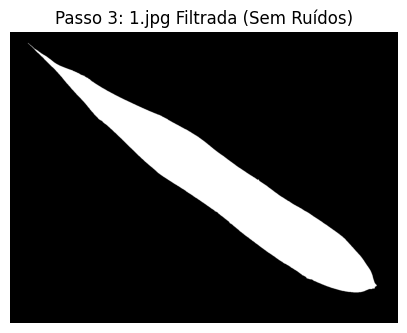

In [29]:
def filtro_abertura_por_area(img_binaria, area_minima):
    h, w = img_binaria.shape
    visitados = np.zeros_like(img_binaria, dtype=bool)
    img_filtrada = np.zeros_like(img_binaria)

    vizinhos = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

    for i in range(h):
        for j in range(w):
            if img_binaria[i, j] == 1 and not visitados[i, j]:
                fila = [(i, j)]
                visitados[i, j] = True
                componente = []

                while fila:
                    atual_i, atual_j = fila.pop(0)
                    componente.append((atual_i, atual_j))

                    for di, dj in vizinhos:
                        ni, nj = atual_i + di, atual_j + dj
                        if 0 <= ni < h and 0 <= nj < w:
                            if img_binaria[ni, nj] == 1 and not visitados[ni, nj]:
                                visitados[ni, nj] = True
                                fila.append((ni, nj))

                if len(componente) >= area_minima:
                    for pixel_i, pixel_j in componente:
                        img_filtrada[pixel_i, pixel_j] = 1

    return img_filtrada

imagem_filtrada = filtro_abertura_por_area(imagem_binaria, area_minima=30)

print(f"=== METADADOS - PASSO 3 (FILTRO DE ÁREA) ===")
print(f"Dimensões da matriz filtrada: {imagem_filtrada.shape}")
print(f"Tipo de dado (Dtype): {imagem_filtrada.dtype}")
print(f"Pixels eliminados (ruídos de fundo): {np.sum(imagem_binaria == 1) - np.sum(imagem_filtrada == 1)}")
print(f"============================================")

plt.figure(figsize=(5, 5))
plt.imshow(imagem_filtrada)
plt.title(f"Passo 3: {ID_TESTE}.jpg Filtrada (Sem Ruídos)")
plt.axis('off')
plt.show()

5 -  Realce de Borda por Gradiente Morfológico Interno

Para extrair a borda precisa da folha, é usado o Gradiente Morfológico Interno.Esta operação algébrica é definida pela subtração matemática da imagem erodida da sua respectiva imagem binária original:

$$\text{Gradiente Interno}(f) = f - \varepsilon_B(f)$$

A erosão ($\varepsilon_B$) reduz os limites do objeto utilizando um elemento estruturante.

Usado um elemento em formato de cruz $3\times3$ (vizinhança), onde um pixel central só permanece ativo se ele e todos os seus quatro vizinhos diretos (acima, abaixo, à esquerda e à direita) forem simultaneamente ativos (1) na imagem sob análise.

=== METADADOS - PASSO 4 (GRADIENTE / BORDA) ===
Dimensões da matriz de bordas: (1200, 1600)
Tipo de dado (Dtype): uint8
Total de pixels que compõem o contorno da folha: 3029


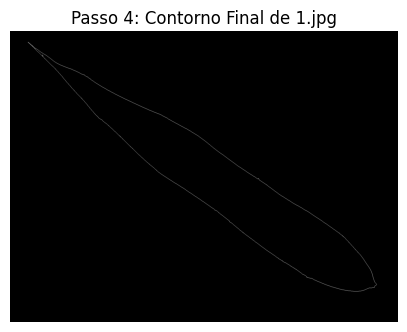

In [30]:
def erosao_vizinhança4(img_binaria):
    h, w = img_binaria.shape
    img_erodida = np.zeros_like(img_binaria)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            if (img_binaria[i, j] == 1 and
                img_binaria[i-1, j] == 1 and
                img_binaria[i+1, j] == 1 and
                img_binaria[i, j-1] == 1 and
                img_binaria[i, j+1] == 1):
                img_erodida[i, j] = 1

    return img_erodida

def gradiente_morfologico_interno(img_binaria):
    img_erodida = erosao_vizinhança4(img_binaria)
    borda_folha = img_binaria - img_erodida
    return borda_folha

imagem_borda = gradiente_morfologico_interno(imagem_filtrada)

print(f"=== METADADOS - PASSO 4 (GRADIENTE / BORDA) ===")
print(f"Dimensões da matriz de bordas: {imagem_borda.shape}")
print(f"Tipo de dado (Dtype): {imagem_borda.dtype}")
print(f"Total de pixels que compõem o contorno da folha: {np.sum(imagem_borda == 1)}")
print(f"===============================================")

plt.figure(figsize=(5, 5))
plt.imshow(imagem_borda)
plt.title(f"Passo 4: Contorno Final de {ID_TESTE}.jpg")
plt.axis('off')
plt.show()

6 - Teste Final com uma variedade de folhas

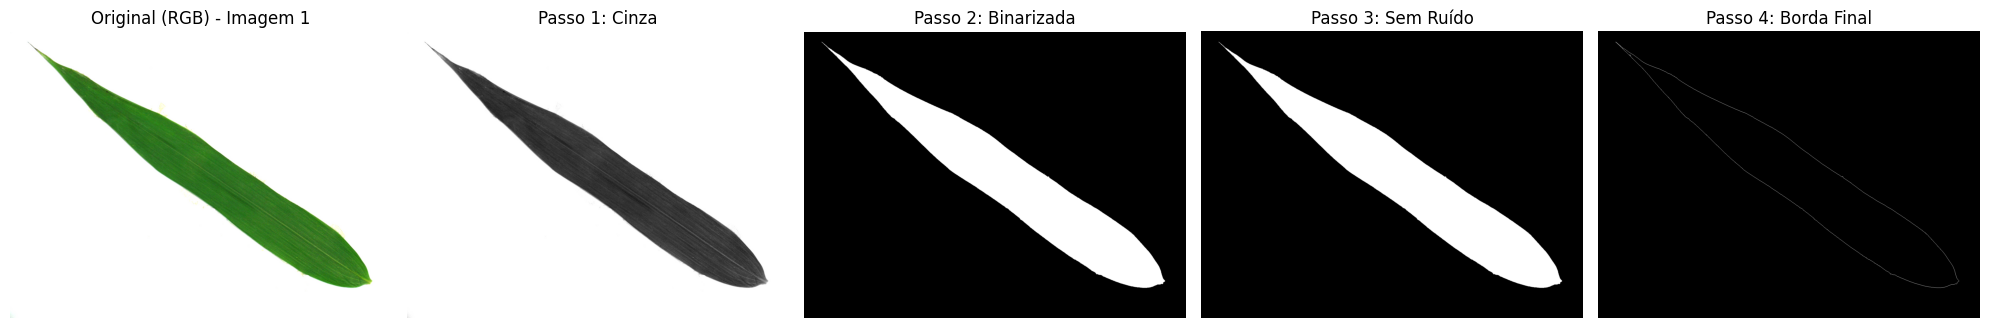

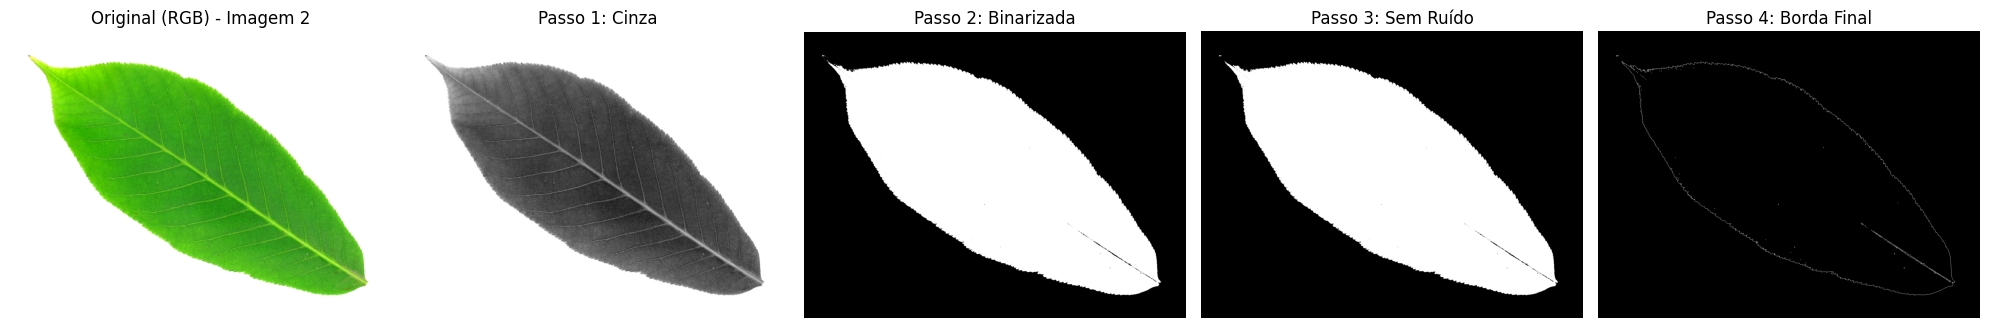

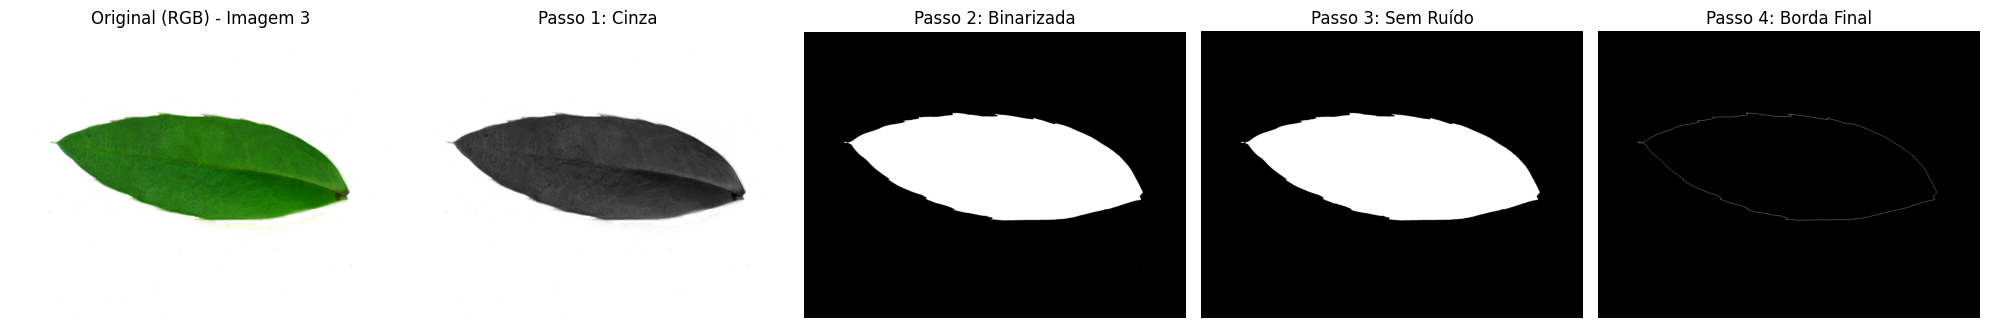

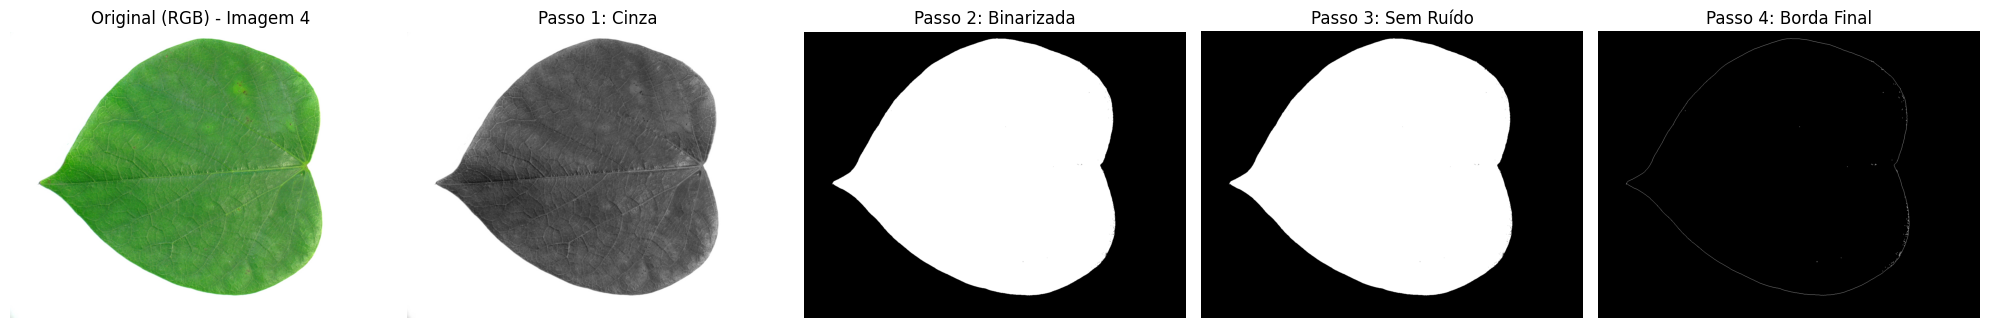

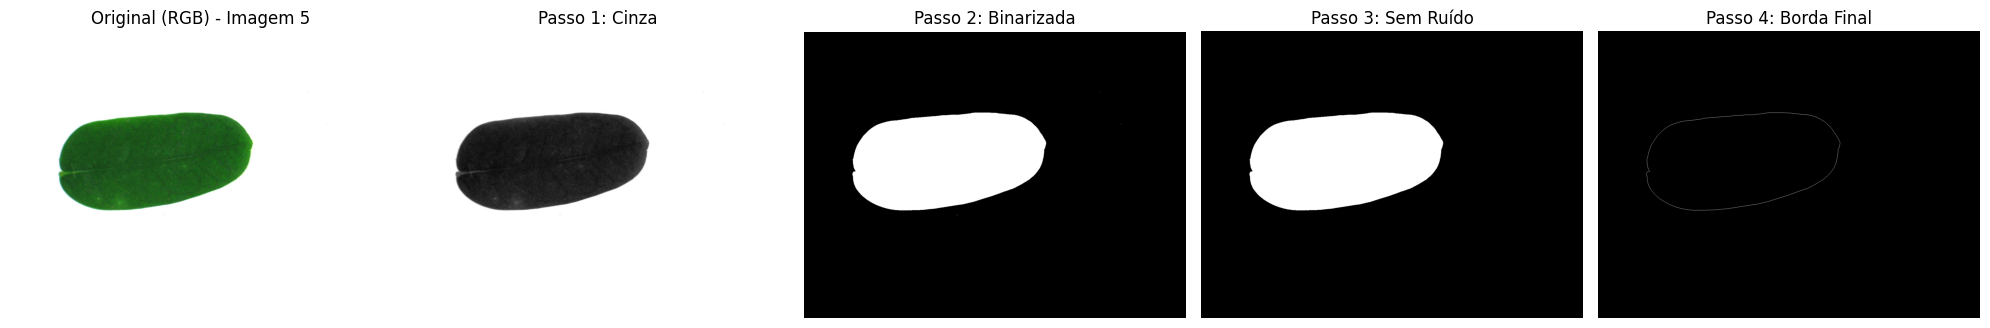

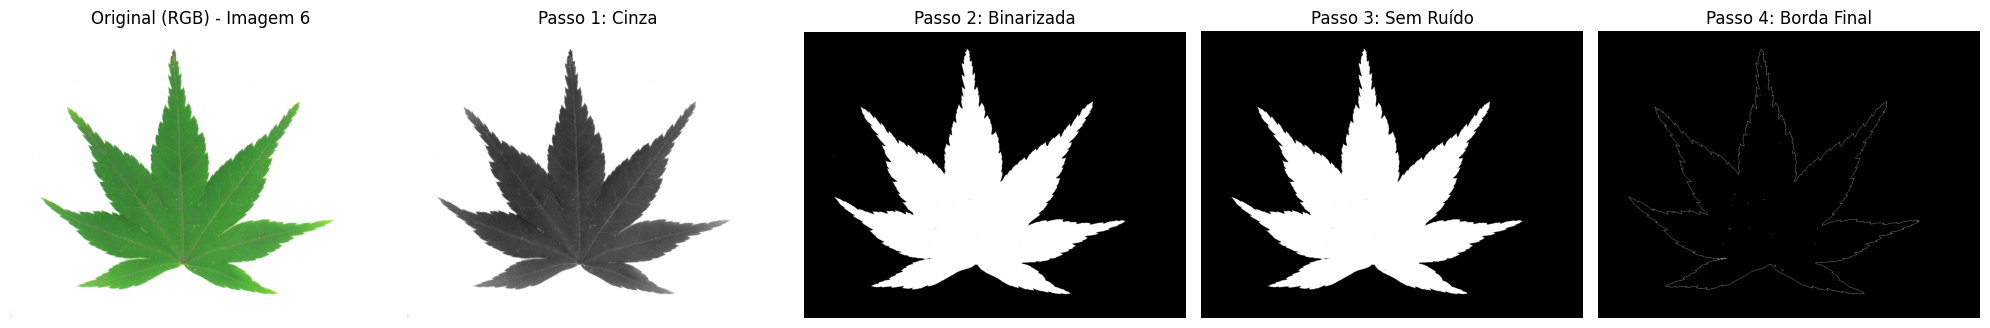

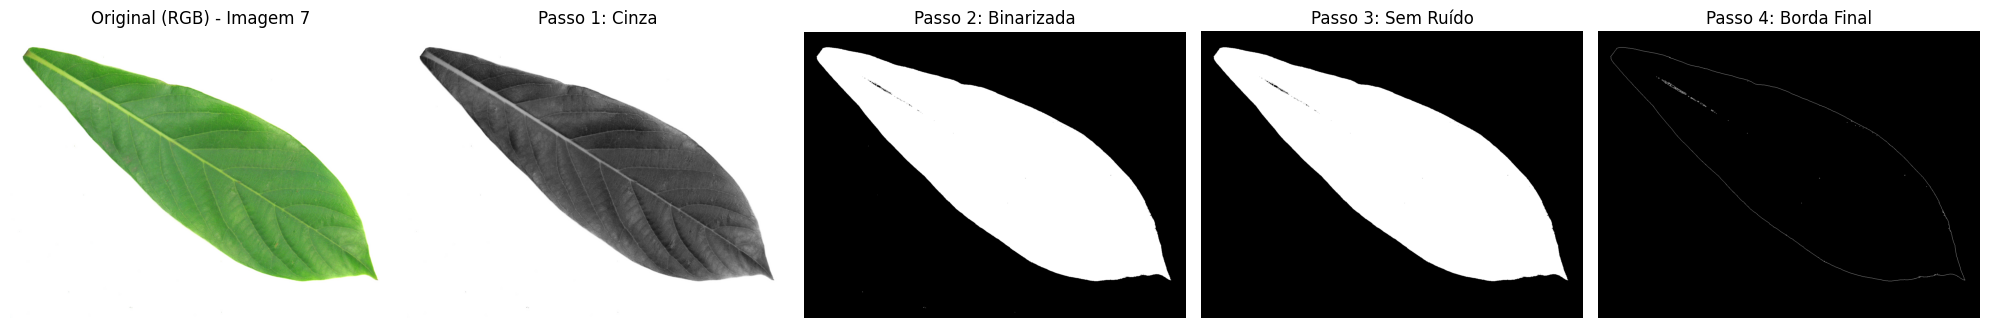

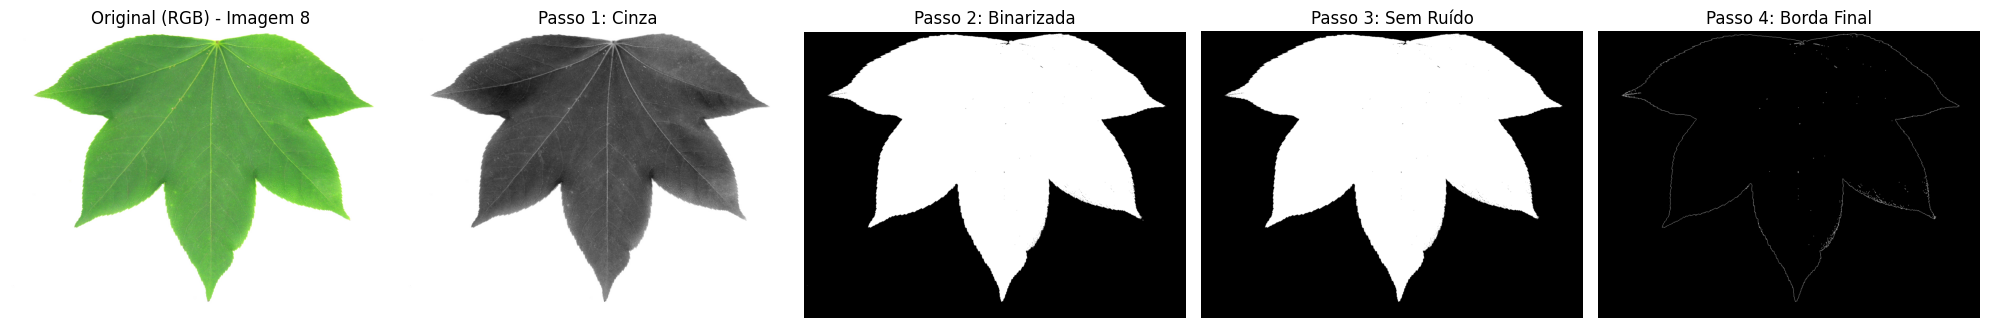

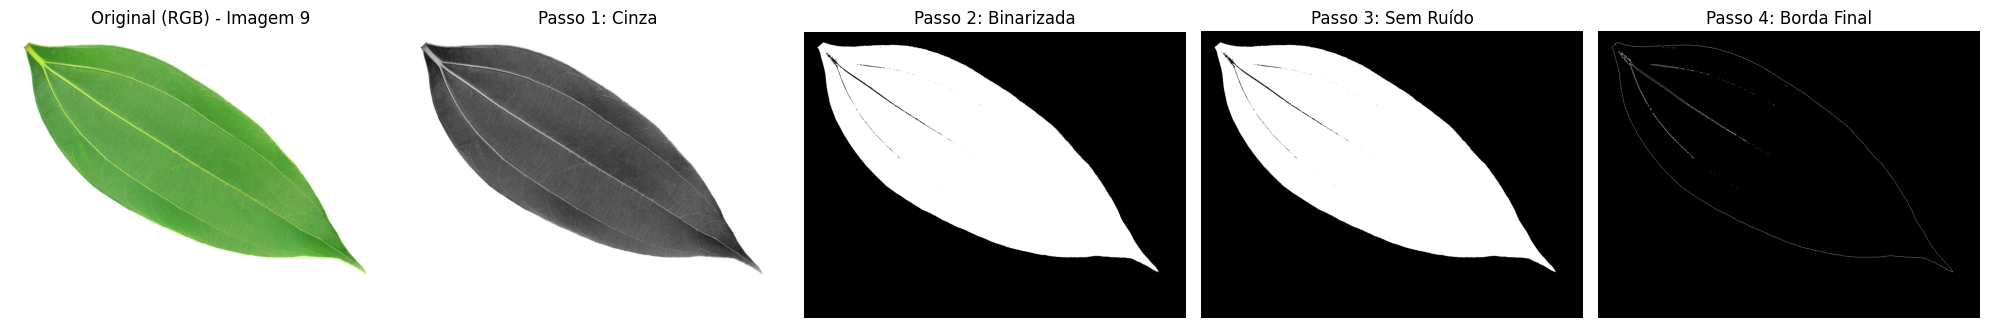

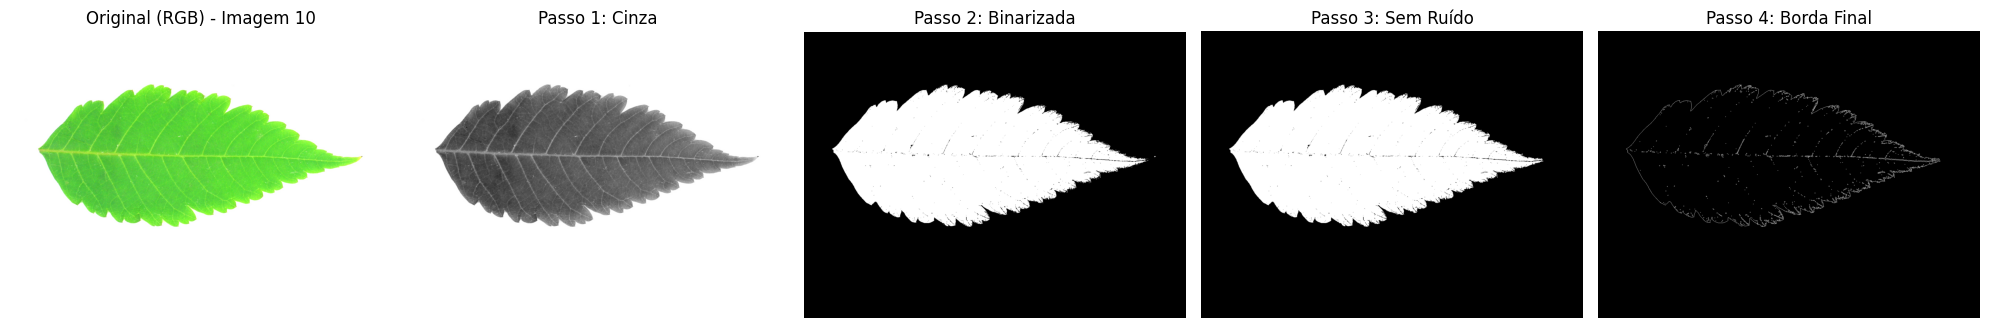

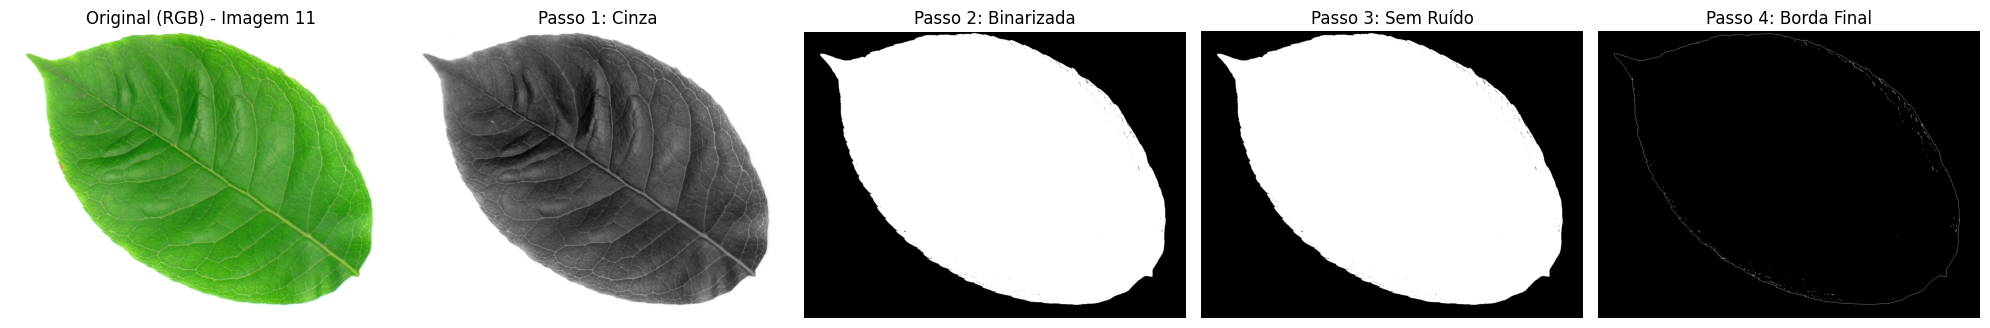

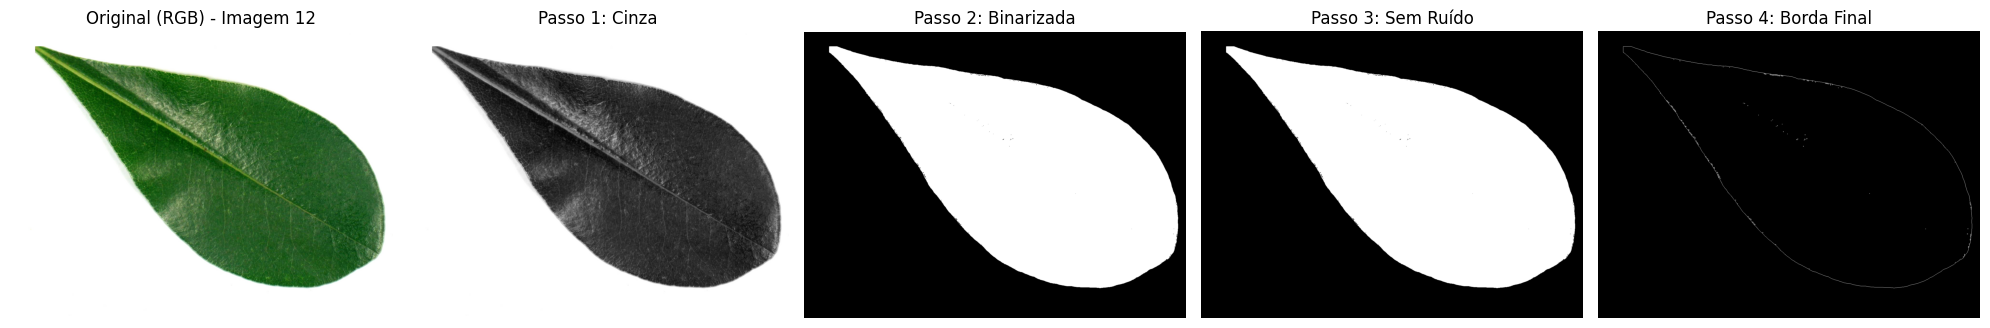

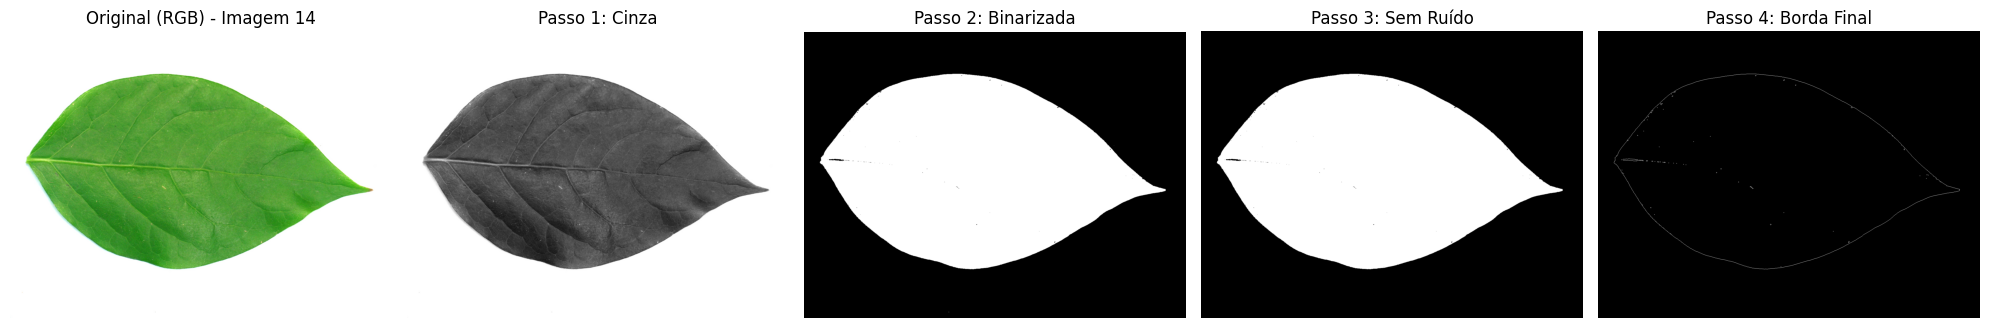

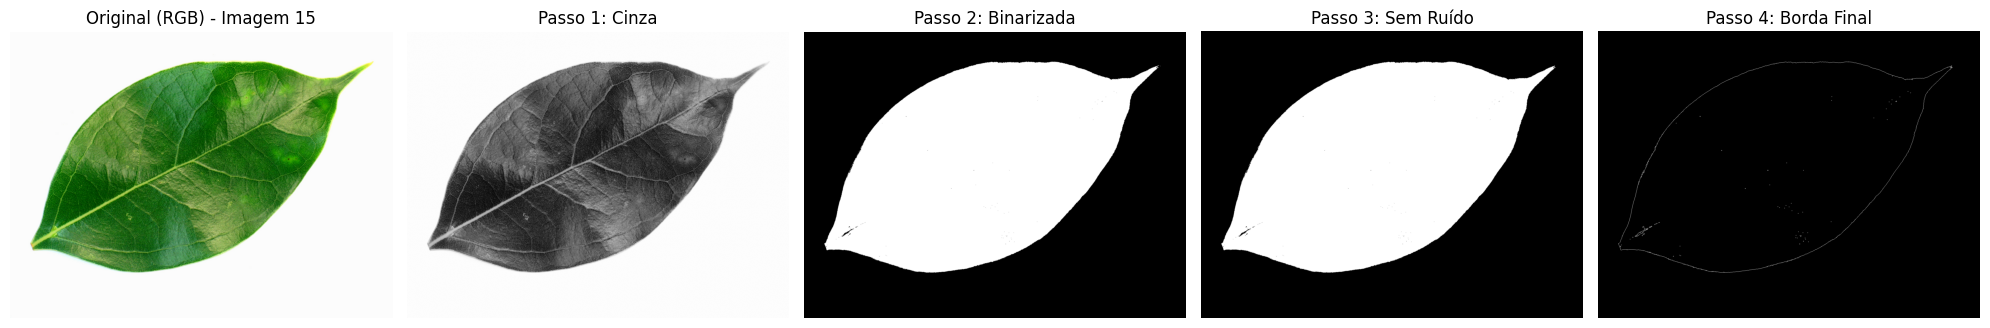

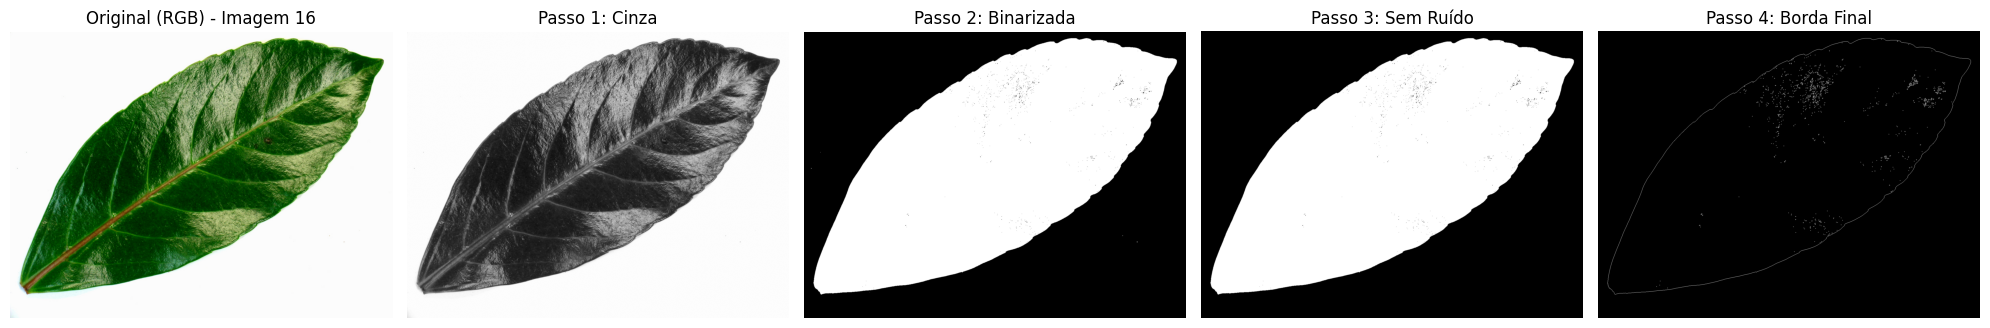

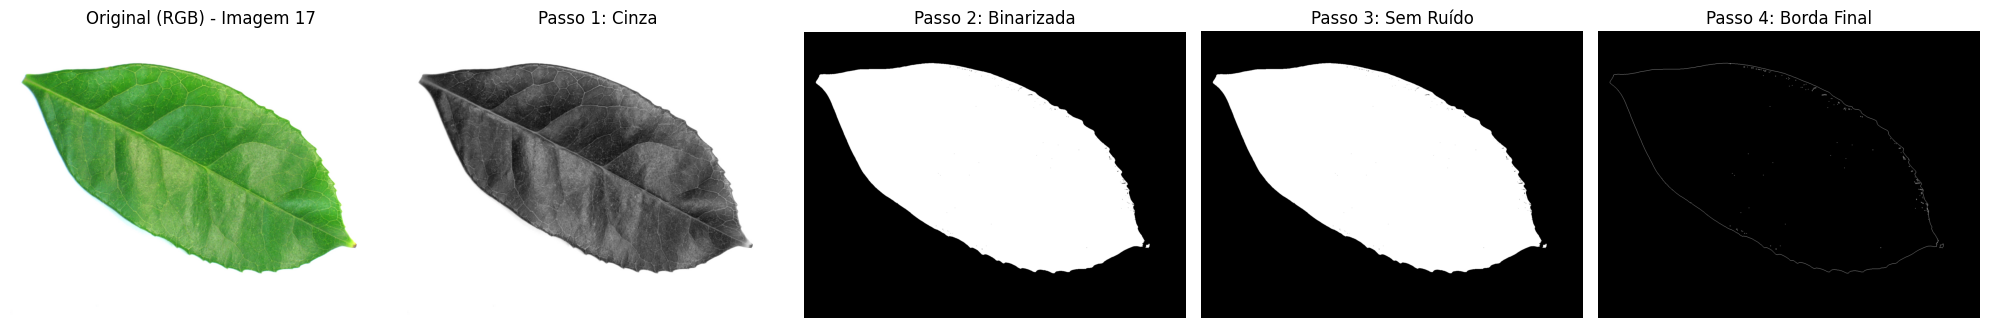

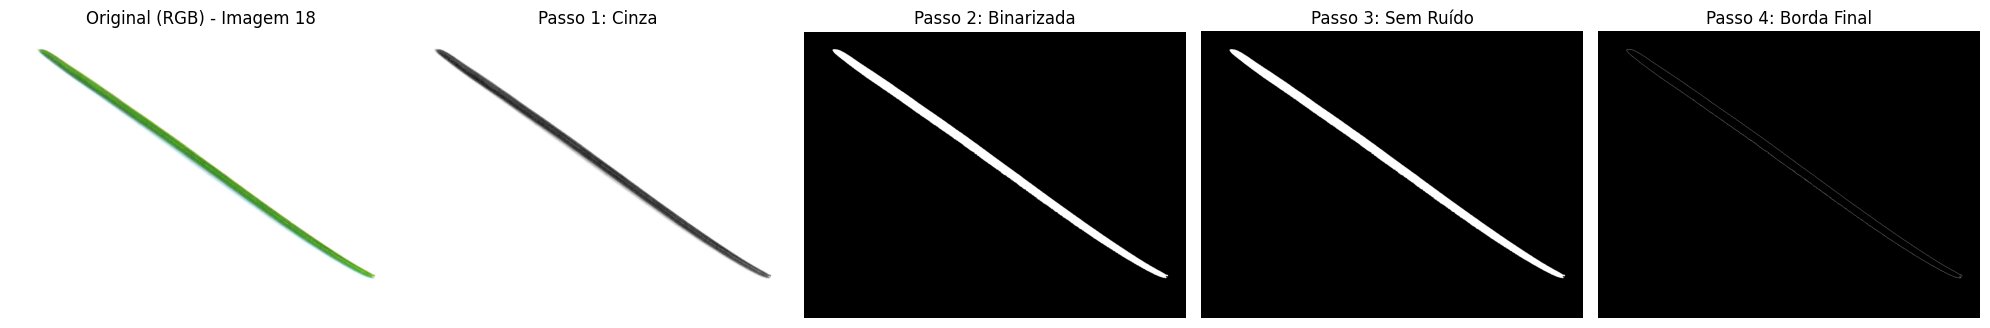

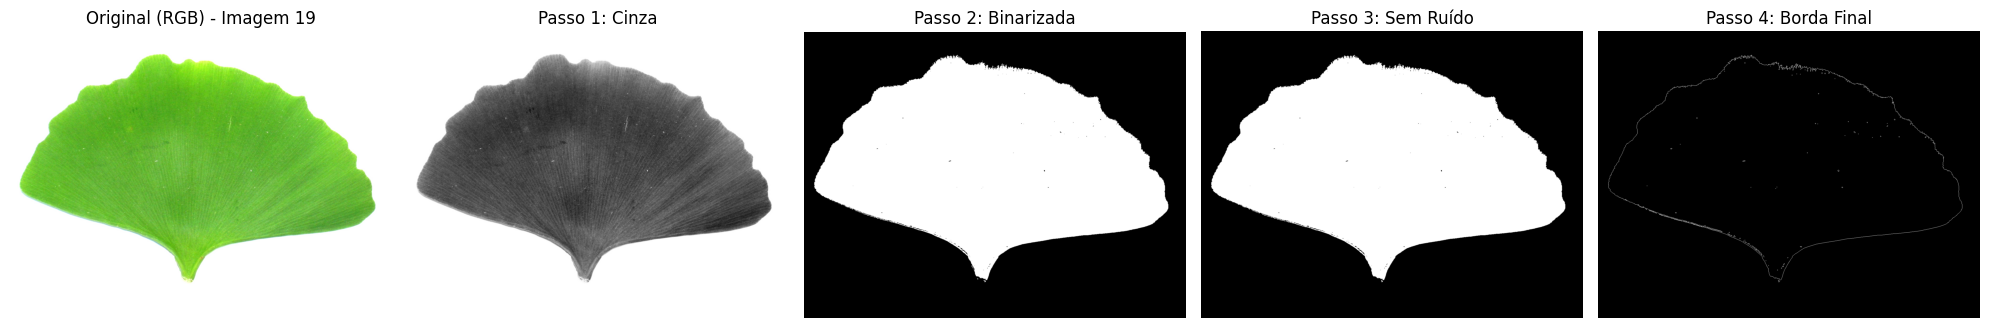

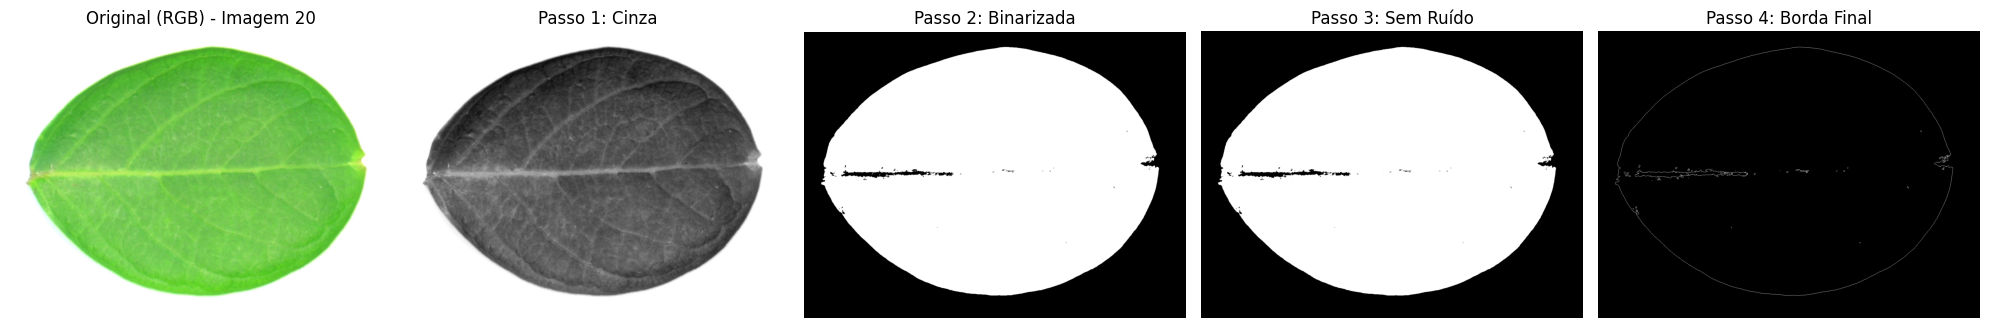

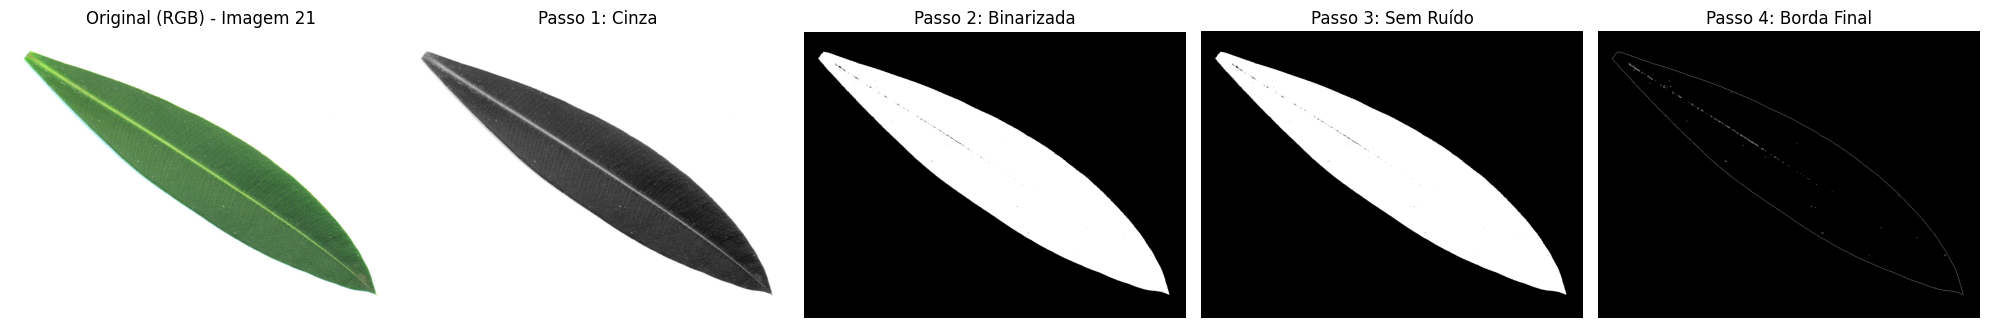

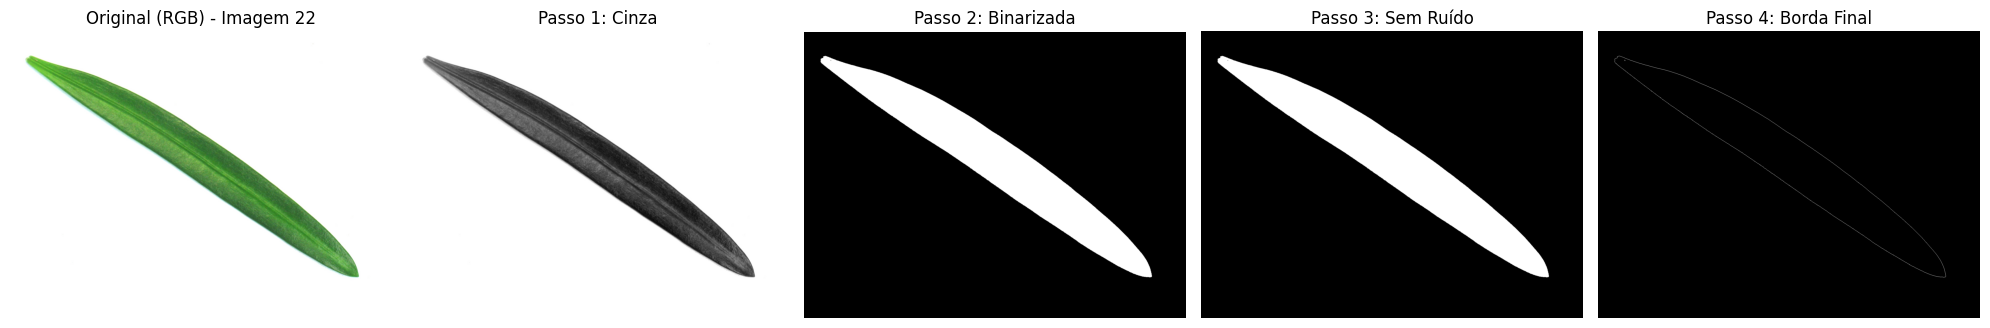

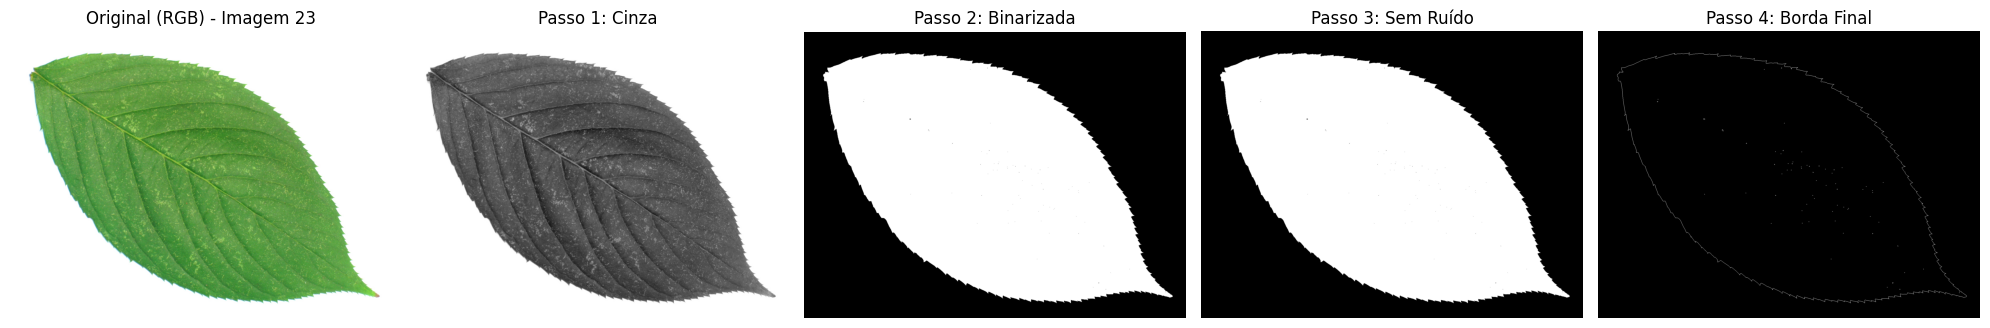

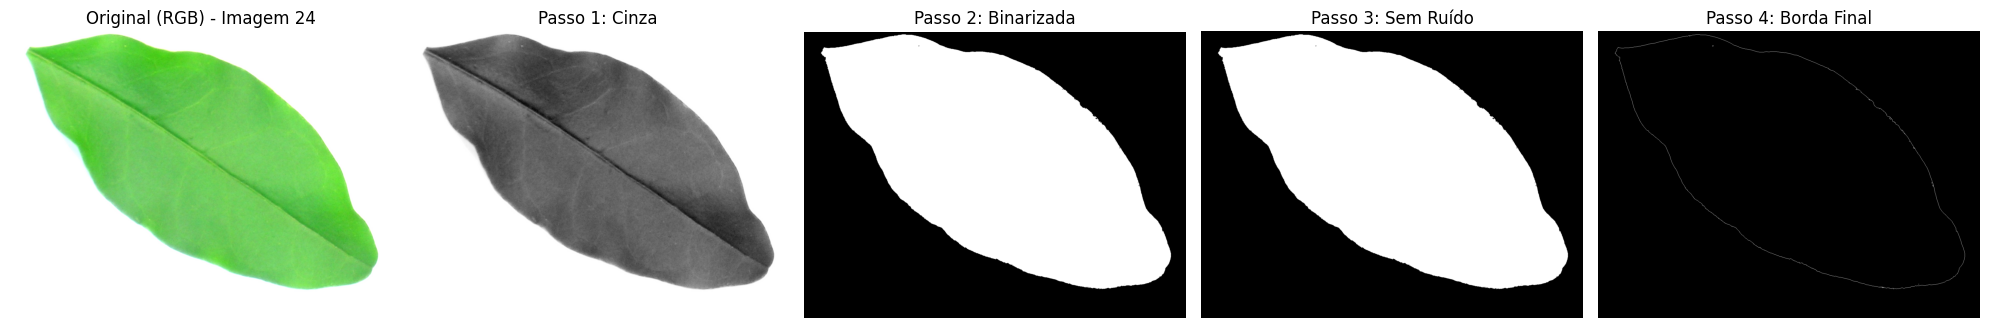

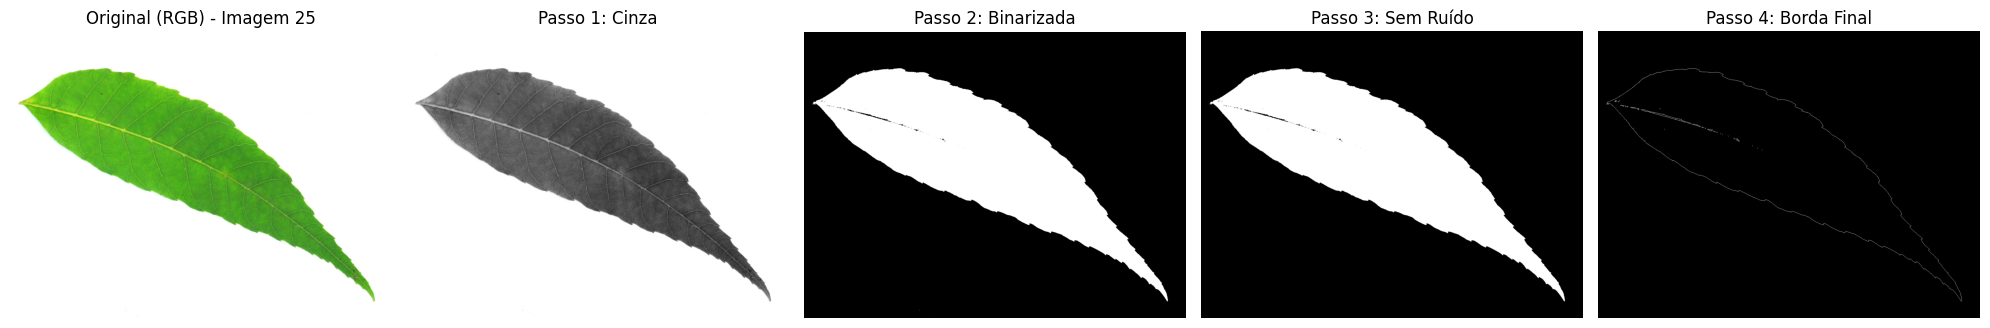

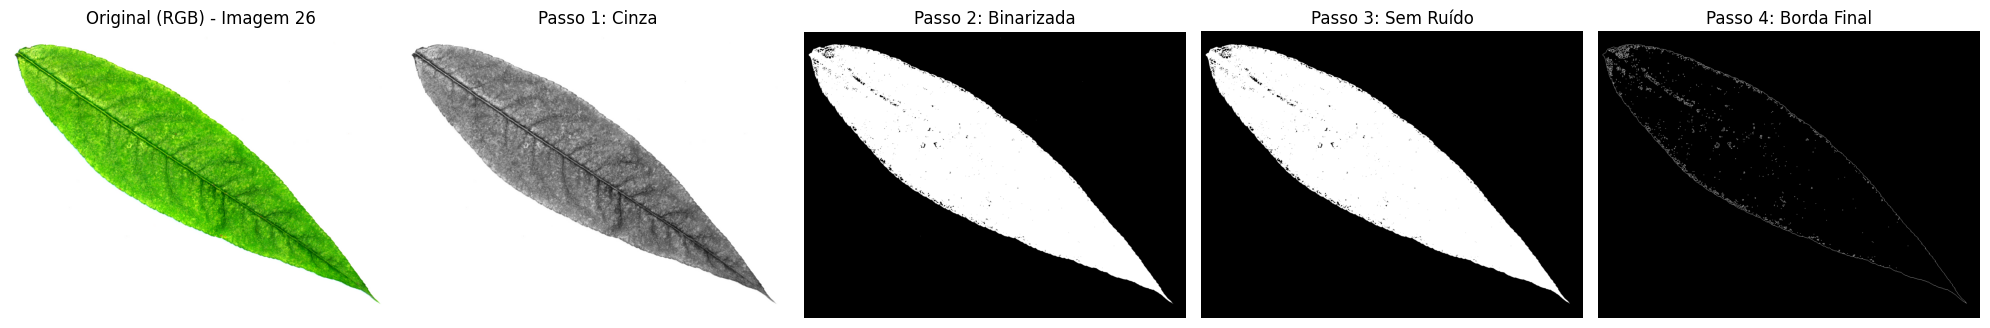

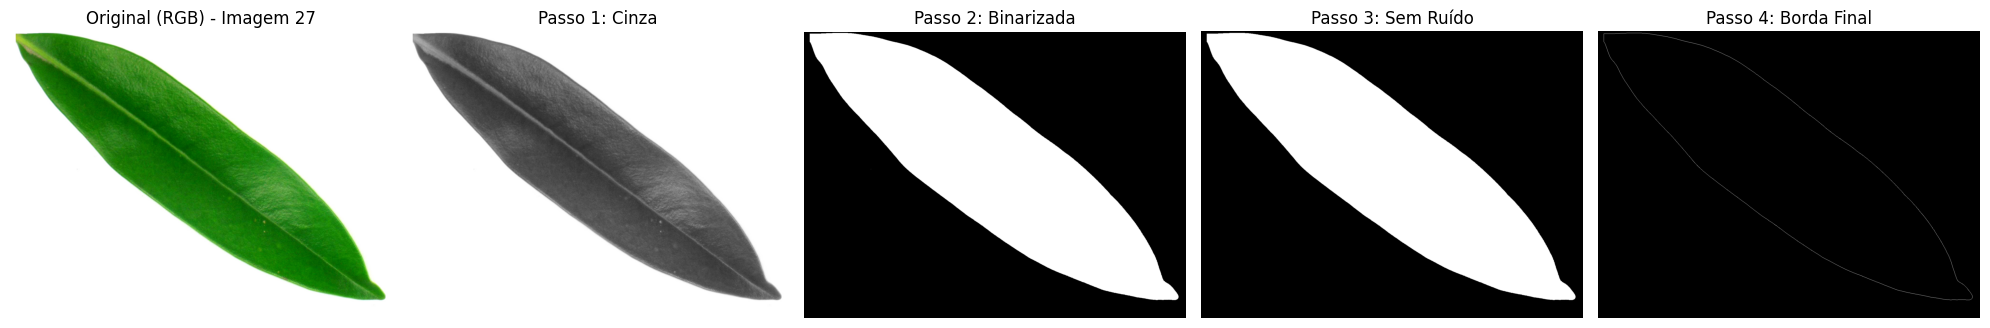

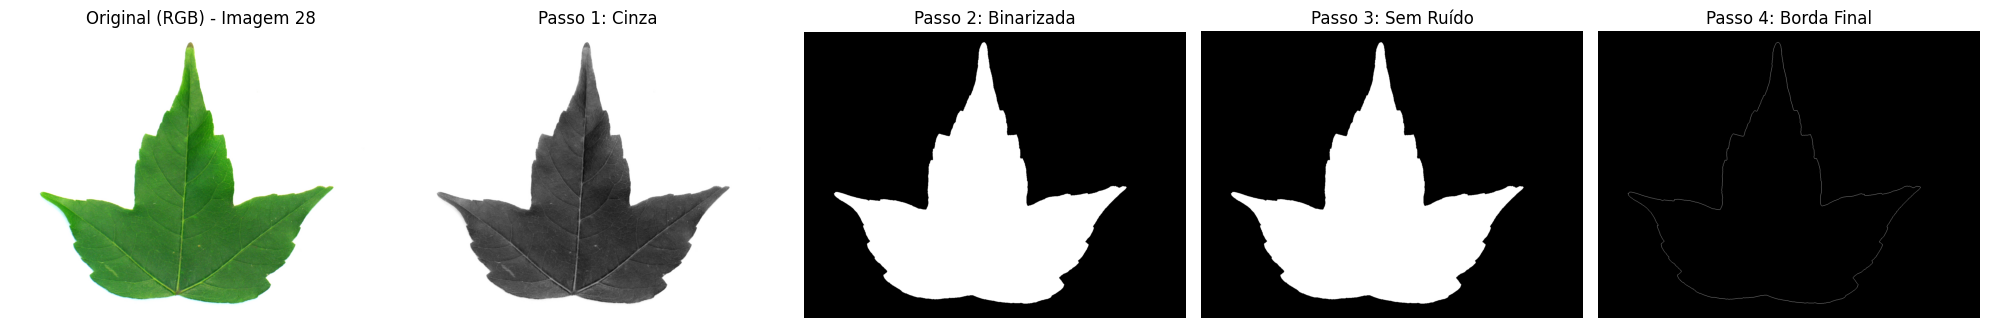

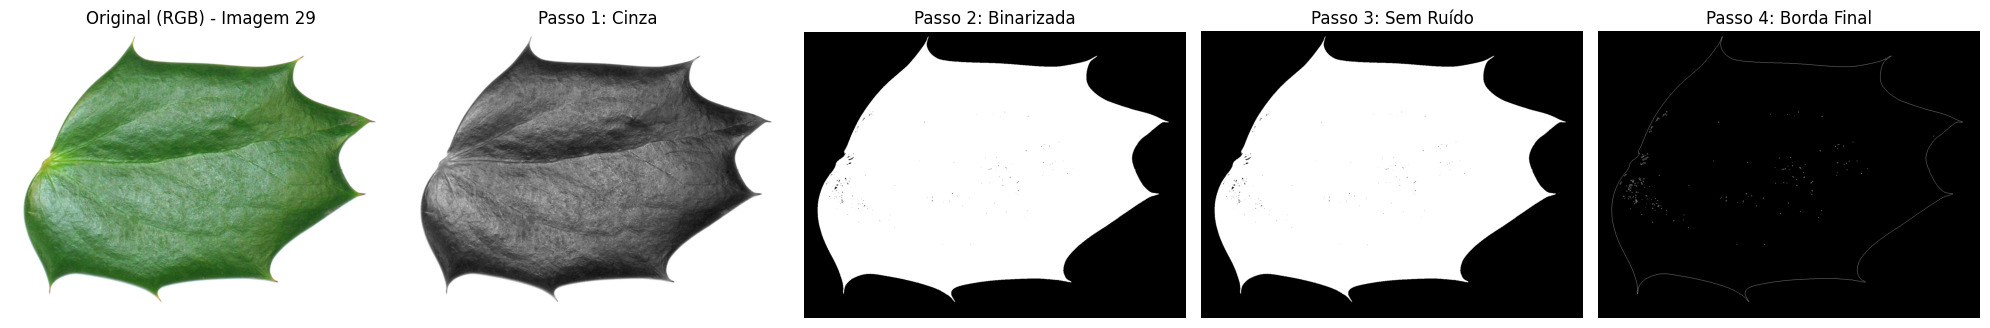

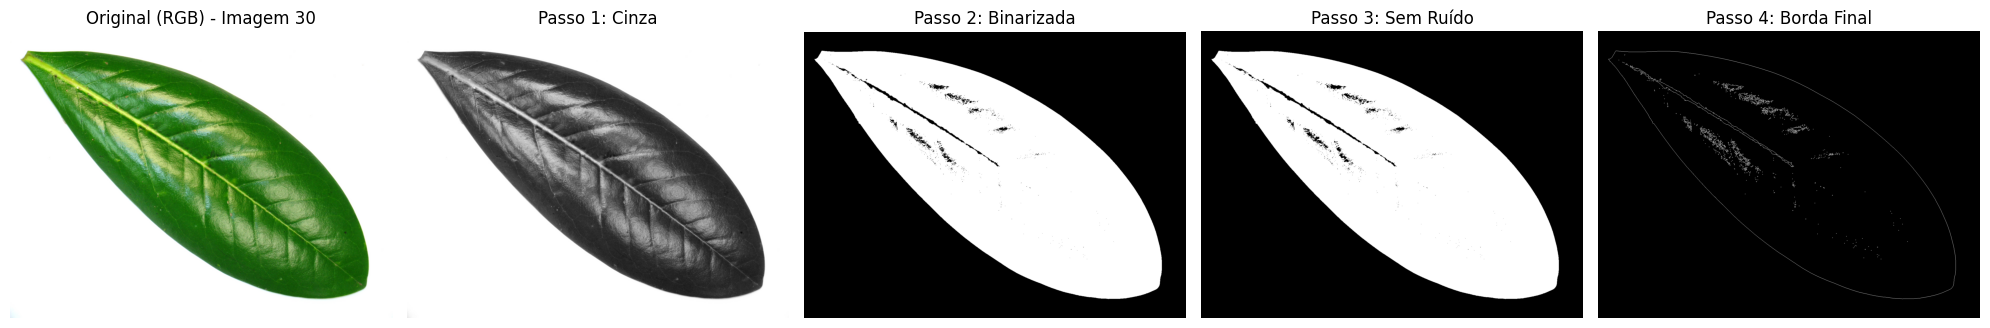

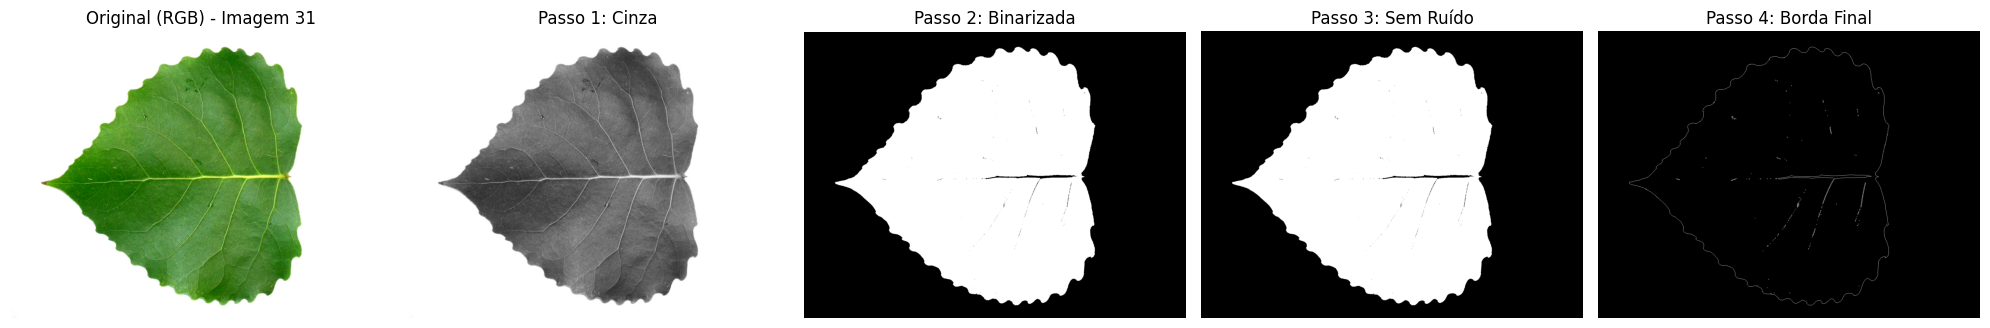

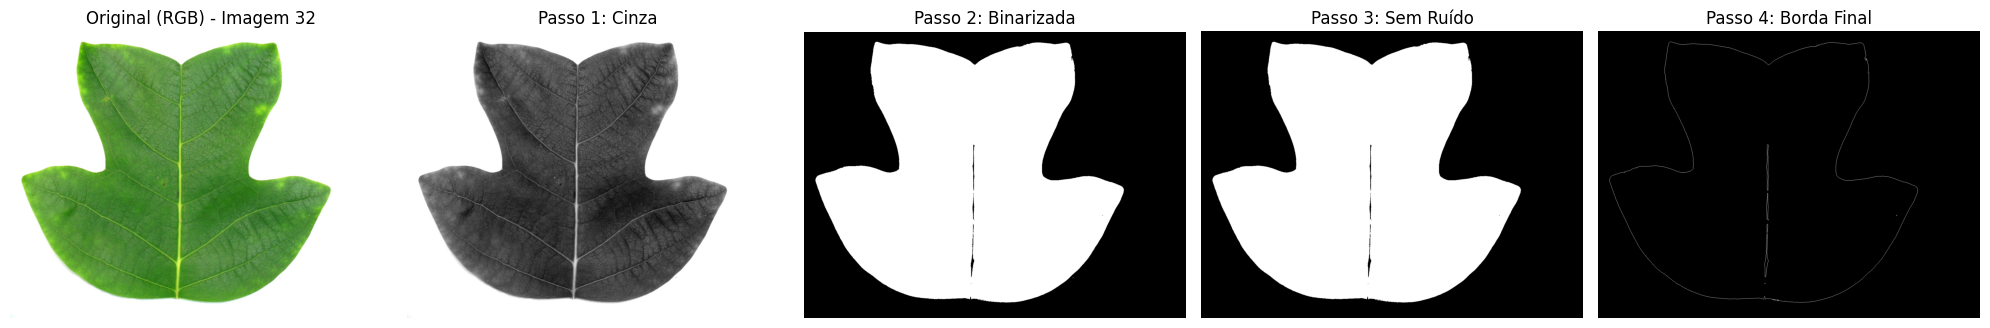

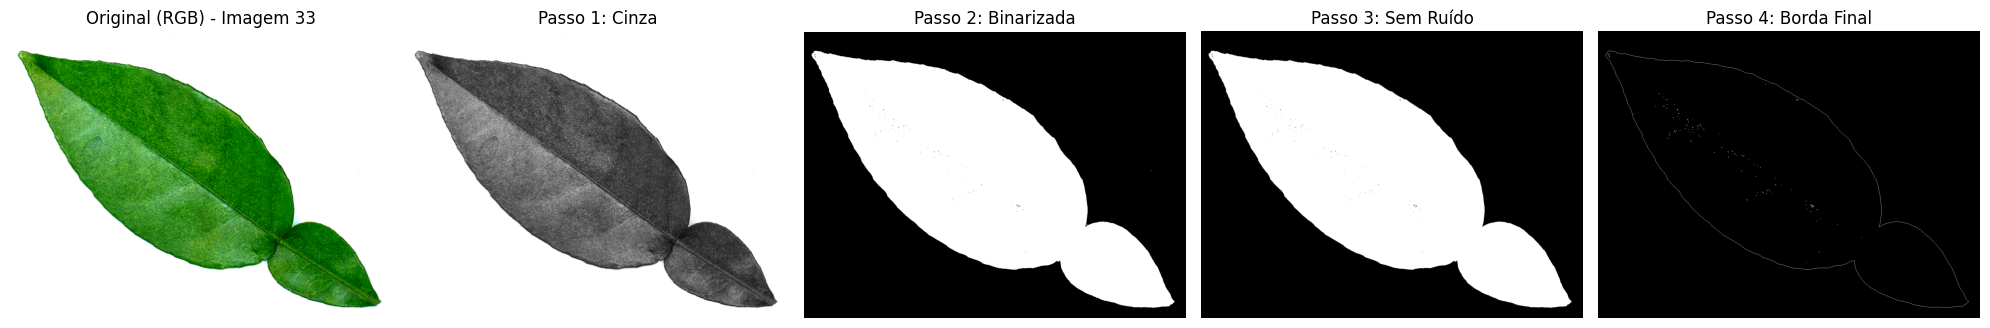

In [39]:
for i in range(1,34):
  if i == 13:
    continue

  ID_TESTE = i

  if ID_TESTE in folhas_dados_direto:
      imagem_original = folhas_dados_direto[ID_TESTE]

      imagem_cinza = rgb_para_cinza(imagem_original)

      imagem_binaria = binarizar_imagem(imagem_cinza, limiar=200)

      imagem_filtrada = filtro_abertura_por_area(imagem_binaria, area_minima=30)

      imagem_borda = gradiente_morfologico_interno(imagem_filtrada)

      fig, axes = plt.subplots(1, 5, figsize=(20, 5))

      axes[0].imshow(imagem_original)
      axes[0].set_title(f"Original (RGB) - Imagem {ID_TESTE}")
      axes[0].axis('off')

      axes[1].imshow(imagem_cinza)
      axes[1].set_title("Passo 1: Cinza")
      axes[1].axis('off')

      axes[2].imshow(imagem_binaria)
      axes[2].set_title("Passo 2: Binarizada")
      axes[2].axis('off')

      axes[3].imshow(imagem_filtrada)
      axes[3].set_title("Passo 3: Sem Ruído")
      axes[3].axis('off')

      axes[4].imshow(imagem_borda)
      axes[4].set_title("Passo 4: Borda Final")
      axes[4].axis('off')

      plt.tight_layout()
      plt.show()
  else:
      print(f"O arquivo {ID_TESTE}.jpg não foi encontrado na memória do dataset.")